In [4]:
import pandas as pd


In [8]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

train.head()                                                                                

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PART 1:DATA CLEANING

1.Check missing values


In [7]:
train.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Set the missing values in the age column to the median age

In [10]:
train["Age"] = train["Age"].fillna(train["Age"].median())

In [11]:
train.isnull().sum()



PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

2. Detect outliers

Outliers are mostly in age and fare
Use boxplot for visualization

In [13]:
import matplotlib.pyplot as plt



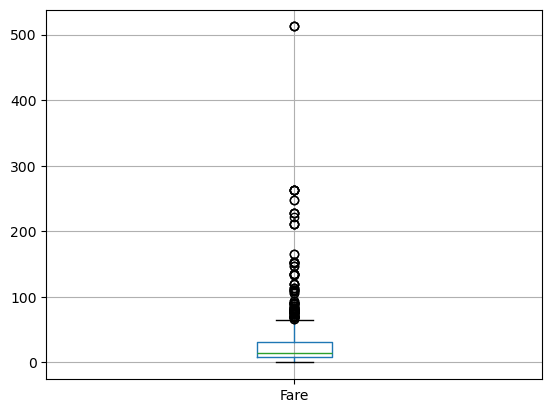

In [14]:
train.boxplot(column="Fare")
plt.show()

Age outliers

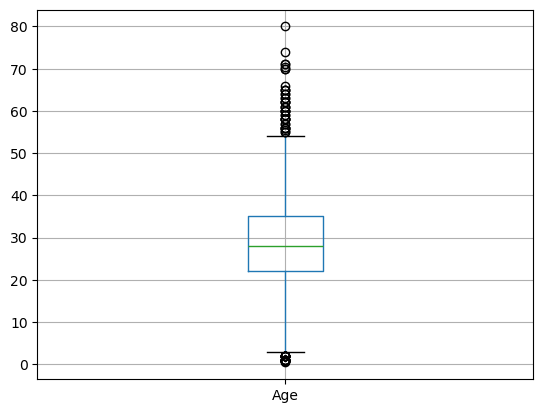

In [15]:
train.boxplot(column="Age")
plt.show()

Cap outliers

In [16]:

Q1 = train["Fare"].quantile(0.25)
Q3 = train["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [18]:

import numpy as np
train["Fare"] = np.where(train["Fare"] > upper, upper, train["Fare"])
train["Fare"] = np.where(train["Fare"] < lower, lower, train["Fare"])

3. Data consistency

Ensure the categorical columns are clean

In [19]:
train["Sex"].unique()

array(['male', 'female'], dtype=object)

Standardize the values

In [20]:
train["Sex"] = train["Sex"].str.lower()


Check for duplicates

In [21]:
train.duplicated().sum()

np.int64(0)

If they exist remove

In [22]:
train = train.drop_duplicates()

Save the clean dataset

In [23]:
train.to_csv("../data/train_cleaned.csv", index=False)

PART2 : FEATURE ENGINEERING

Load clean dataset

In [24]:

import pandas as pd
import numpy as np

train = pd.read_csv("../data/train_cleaned.csv")

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,65.6344,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


1. Family size

In [25]:
 
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1

Check results

In [26]:
train[["SibSp","Parch","FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


2. Is alone

In [28]:
train["IsAlone"] = np.where(train["FamilySize"] == 1, 1, 0)

In [29]:
train[["FamilySize","IsAlone"]].head()

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


3. Extract title from name

In [30]:

train["Title"] = train["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)

In [31]:
#Check unique titles
train["Title"].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

Simplify rare titles

In [32]:

rare_titles = ["Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"]

train["Title"] = train["Title"].replace(rare_titles, "Rare")
train["Title"] = train["Title"].replace("Mlle","Miss")
train["Title"] = train["Title"].replace("Ms","Miss")
train["Title"] = train["Title"].replace("Mme","Mrs")

4. Deck extraction

In [34]:
train["Deck"] = train["Cabin"].str[0]
train["Deck"].fillna("Unknown", inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_15960\363452764.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train["Deck"].fillna("Unknown", inplace=True)


5. Age groups

In [35]:

bins = [0, 12, 19, 60, 120]
labels = ["Child","Teen","Adult","Senior"]

train["AgeGroup"] = pd.cut(train["Age"], bins=bins, labels=labels)

In [36]:
train[["Age","AgeGroup"]].head()

,Age,AgeGroup
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult


6. Fare per person

In [37]:

train["FarePerPerson"] = train["Fare"] / train["FamilySize"]

7.Categorical encoding

Converting categories into numbers

In [38]:
train = pd.get_dummies(train, columns=["Sex","Embarked","Title","AgeGroup"], drop_first=True)

8. Feature transformation

Log transform skewed data

In [39]:
train["Fare"] = np.log1p(train["Fare"])

Scaling

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train[["Age","Fare"]] = scaler.fit_transform(train[["Age","Fare"]])

Fare distribution

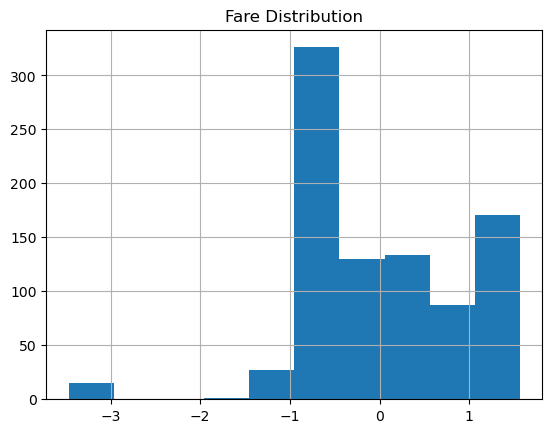

In [41]:

import matplotlib.pyplot as plt

train["Fare"].hist()
plt.title("Fare Distribution")
plt.show()




Age distribution

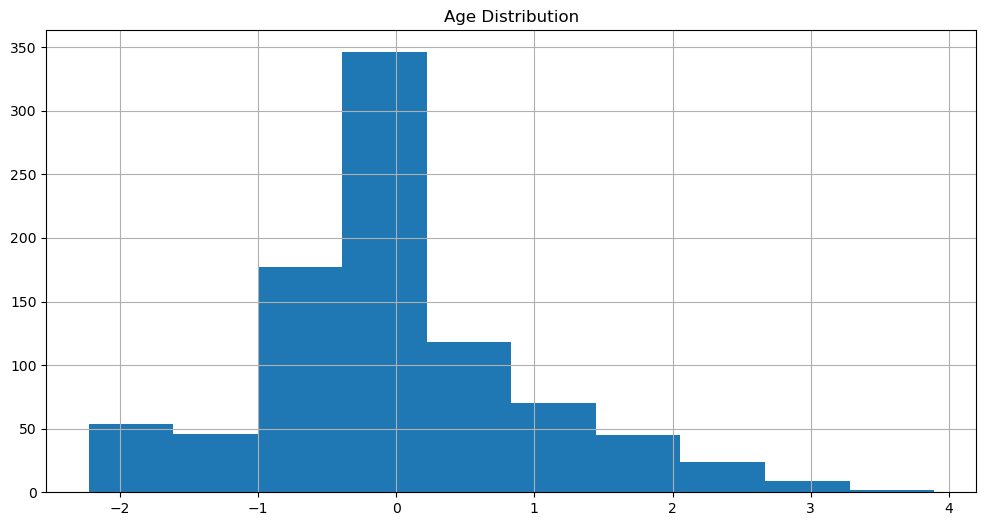

In [65]:

import matplotlib.pyplot as plt

train["Age"].hist()
plt.title("Age Distribution")
plt.show()




Save engineered dataset

In [44]:

train.to_csv("../data/train_engineered.csv", index=False)


PART 3: FEATURE SELECTION

Load engineered dataset


In [45]:

import pandas as pd
train = pd.read_csv("../data/train_engineered.csv")
train.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,...,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,AgeGroup_Teen,AgeGroup_Adult,AgeGroup_Senior
0,1,0,3,"Braund, Mr. Owen Harris",-0.565736,1,0,A/5 21171,-0.937738,NaN,...,True,False,True,False,True,False,False,False,True,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.663861,1,0,PC 17599,1.563065,C85,...,False,False,False,False,False,True,False,False,True,False
2,3,1,3,"Heikkinen, Miss. Laina",-0.258337,0,0,STON/O2. 3101282,-0.843593,NaN,...,False,False,True,True,False,False,False,False,True,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.433312,1,0,113803,1.313600,C123,...,False,False,True,False,False,True,False,False,True,False
4,5,0,3,"Allen, Mr. William Henry",0.433312,0,0,373450,-0.826943,NaN,...,True,False,True,False,True,False,False,False,True,False


1. Correlation analysis

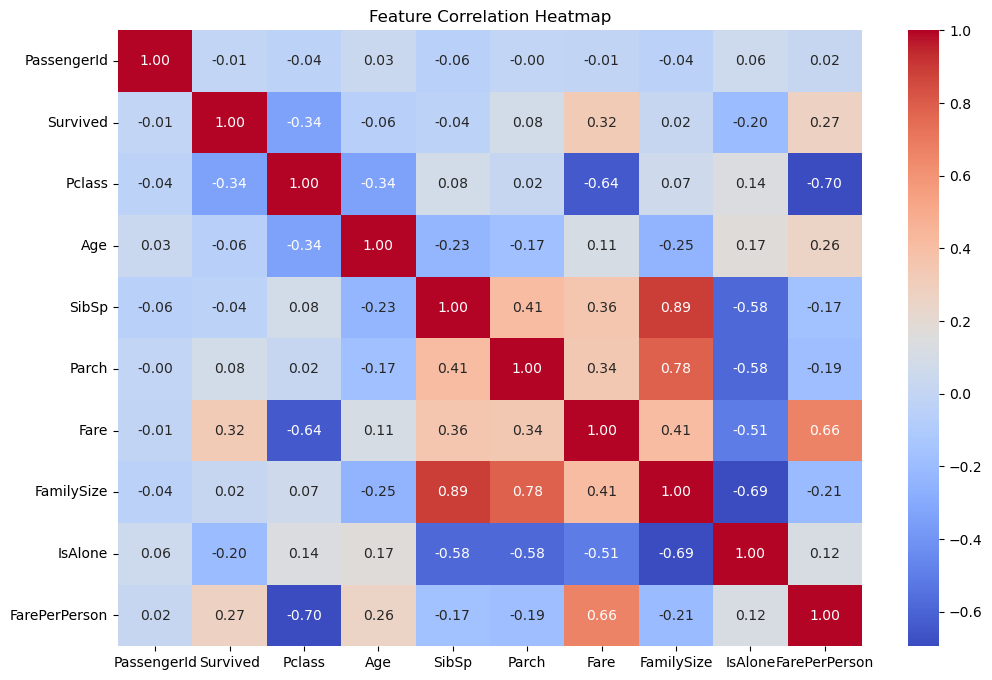

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Keep only numeric columns
numeric_cols = train.select_dtypes(include=['int64', 'float64'])

# Compute correlation
corr = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

2.Feature importance(Random forest)

In [57]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

train = pd.read_csv("../data/train_engineered.csv")

cols_to_drop = ["Survived", "Name", "Ticket", "Cabin"]
cols_to_drop = [c for c in cols_to_drop if c in train.columns]

X = train.drop(columns=cols_to_drop)
y = train["Survived"]

# CLEAN DATA PROPERLY
X = X.replace("Unknown", pd.NA)
X = X.fillna(0)
X = pd.get_dummies(X, drop_first=True)

# TRAIN
model = RandomForestClassifier()
model.fit(X, y)

# IMPORTANCE
importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

PassengerId        0.137964
Age                0.117386
FarePerPerson      0.116530
Fare               0.113578
Sex_male           0.113464
Title_Mr           0.113138
Pclass             0.048975
FamilySize         0.041459
Title_Miss         0.036304
Title_Mrs          0.026168
SibSp              0.025608
Embarked_S         0.017172
Parch              0.014607
AgeGroup_Adult     0.010477
Deck_E             0.009403
IsAlone            0.007758
Embarked_Q         0.007631
Deck_C             0.007542
Title_Rare         0.007242
Deck_D             0.006745
AgeGroup_Teen      0.006160
Deck_B             0.005259
Deck_A             0.003126
AgeGroup_Senior    0.002967
Deck_F             0.002011
Deck_G             0.001183
Deck_T             0.000142
dtype: float64


3.Recursive feature elimination

In [63]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

selector = RFE(model, n_features_to_select=10)
selector.fit(X, y)

selected_features = X.columns[selector.support_]
print(selected_features)

Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Fare', 'FamilySize',
       'FarePerPerson', 'Sex_male', 'Title_Mr', 'Title_Mrs'],
      dtype='object')


In [64]:
from sklearn.feature_selection import RFE

selector = RFE(model, n_features_to_select=10)
selector.fit(X,y)

,estimator,RandomForestC...ndom_state=42)
,n_features_to_select,10
,step,1
,verbose,0
,importance_getter,'auto'
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
